In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Load the data
try:
    df = pd.read_csv(
        '../table_tennis_data/table_tennis.txt',
        sep=' ',
        header=None,
        names=['filename', 'label']
    )
except FileNotFoundError:
    print("Error: The annotation file was not found.")

In [4]:
# action mapping
action_mapping = {
    "zero": {"category": "Zero", "id": 0},
    "drive": {"category": "Attack", "id": 1},
    "counter drive": {"category": "Attack", "id": 2},
    "smash": {"category": "Attack", "id": 3},
    "backhand twist": {"category": "Attack", "id": 4},
    "fast drive": {"category": "Attack", "id": 5},
    "fast push": {"category": "Attack", "id": 6},
    "flip": {"category": "Attack", "id": 7},
    "pimple’s long push": {"category": "Control", "id": 8},
    "pimple’s fast push": {"category": "Control", "id": 9},
    "long push": {"category": "Control", "id": 10},
    "drop shot": {"category": "Control", "id": 11},
    "chop": {"category": "Defensive", "id": 12},
    "block": {"category": "Defensive", "id": 13},
    "lob": {"category": "Defensive", "id": 14},
    "traditional": {"category": "Serve", "id": 15},
    "hook": {"category": "Serve", "id": 16},
    "reverse": {"category": "Serve", "id": 17},
    "squat": {"category": "Serve", "id": 18},
}

id_to_name = {info["id"]: action for action, info in action_mapping.items()}

/tmp/ipykernel_727891/2231167703.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_727891/2231167703.py:15: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


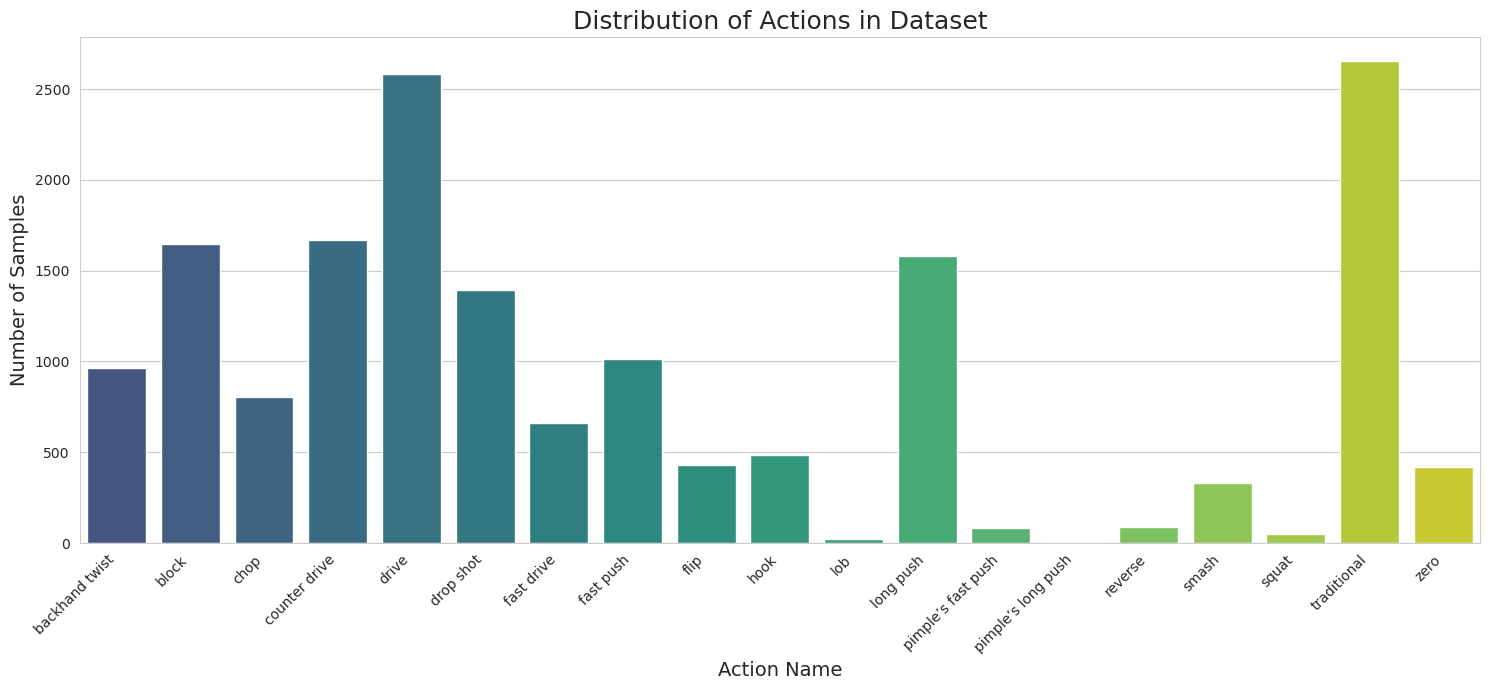

In [5]:
# Convert numeric labels → readable names
df["action_name"] = df["label"].map(id_to_name)

# Count occurrences
action_counts = df["action_name"].value_counts().sort_index()

# === Generate gradient colors ===
cmap = plt.get_cmap("viridis")   # sleek gradient options: "viridis", "magma", "plasma", "cividis", "cool"
colors = cmap(np.linspace(0.25, 0.95, len(action_counts)))

# === Plot ===
plt.figure(figsize=(15, 7))
sns.set_style("whitegrid")

sns.barplot(
    x=action_counts.index,
    y=action_counts.values,
    palette=colors
)

plt.title("Distribution of Actions in Dataset", fontsize=18)
plt.xlabel("Action Name", fontsize=14)
plt.ylabel("Number of Samples", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

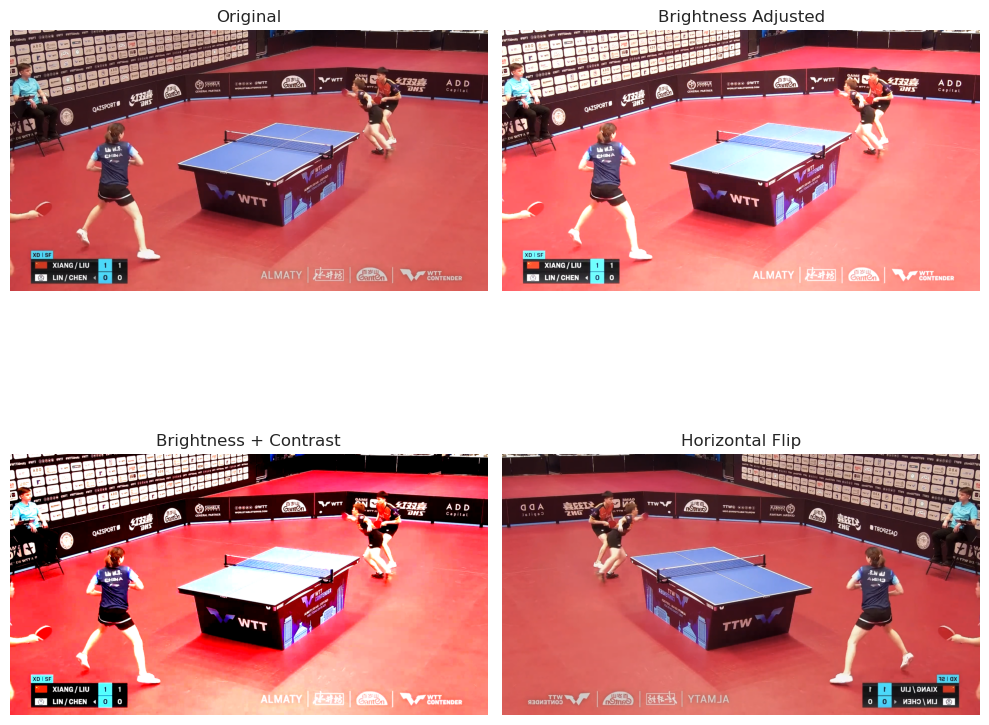

In [8]:
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt

# Load image
img_path = "sample.png"   # change to your file path
img = Image.open(img_path)

# --- Adjust Brightness ---
brightness_factor = 1.5   # 1.0 = original, <1 darker, >1 brighter
bright_enhancer = ImageEnhance.Brightness(img)
bright_img = bright_enhancer.enhance(brightness_factor)

# --- Adjust Contrast ---
contrast_factor = 1.8     # 1.0 = original, <1 lower contrast, >1 higher
contrast_enhancer = ImageEnhance.Contrast(bright_img)
contrast_img = contrast_enhancer.enhance(contrast_factor)

# --- Horizontal Flip ---
flip_img = img.transpose(Image.FLIP_LEFT_RIGHT)

# Plot (2x2)
plt.figure(figsize=(10,10))

plt.subplot(2,2,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(2,2,2)
plt.title("Brightness Adjusted")
plt.imshow(bright_img)
plt.axis("off")

plt.subplot(2,2,3)
plt.title("Brightness + Contrast")
plt.imshow(contrast_img)
plt.axis("off")

plt.subplot(2,2,4)
plt.title("Horizontal Flip")
plt.imshow(flip_img)
plt.axis("off")

plt.tight_layout()
plt.show()
